In [1]:
%matplotlib inline
import sys
import os
import time
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
import os

notebook_path = os.getcwd()
print(notebook_path)

/scratch/ff2183/Causality-Simple-Models/CdV-Good/Physics-constrained/Sequential/Local_Standardization/General_code/Discrete/Test_To_Share/Energy_Conserving


In [3]:
def to_zero_mean_unit_variance(x,mean_i,std_i):
    
    # Input: 
    # np.shape(x) = (Dimension, Time)
    # sigma of each x[i]
    # Output: x_std, where each x[i] is zero mean and unit variance
    
    # For each component of x_t, divide by its sigma
    x_t_std = x.copy()
    for i in range(len(std_i)):
        x_t_std[i] = (x[i]-mean_i[i])/std_i[i]
        
    return x_t_std

Note: in the training procedure I refer to the validation set as test set. 
Worst mistakes have been committed in history.

## Load data

In [4]:
x_t_all = np.load('../../../../../../../Numerical/results/CdV_long_trajectory.npy').T
x_t_all = x_t_all[:,:] #10000001
x_t_all.shape

(6, 10000001)

In [5]:
# Inputs

# ~95% training
x_t_TRAIN = x_t_all[:,0:9000000].copy()#45000000
# Consider years 500-600 for testing
x_t_TESTING = x_t_all[:,9000000:].copy()

# Mean and standard deviation of the training set
train_mean_i = np.mean(x_t_TRAIN,1)
train_std_i = np.std(x_t_TRAIN,1)

np.save('./results/train_mean_i.npy',train_mean_i)
np.save('./results/train_std_i.npy',train_std_i)

# Standardize the two
x_t_TRAIN_std = to_zero_mean_unit_variance(x_t_TRAIN,train_mean_i,train_std_i)
x_t_TESTING_std = to_zero_mean_unit_variance(x_t_TESTING,train_mean_i,train_std_i)

np.save('./results/x_t_TRAIN_std.npy',x_t_TRAIN_std)
np.save('./results/x_t_TESTING_std.npy',x_t_TESTING_std)

In [6]:
x_t_TRAIN.shape

(6, 9000000)

In [7]:
x_t_TESTING.shape

(6, 1000001)

In [8]:
del x_t_all

## Step (a): define training and testing

In [9]:
x_t_TRAIN_std.shape

(6, 9000000)

In [10]:
###### Defining inputs and targets for discrete mapping

# The inputs are the current states (x_t)
x_t_TRAIN = x_t_TRAIN_std[:, 0:-1] 
# The targets are the exact next states (x_{t+1})
x_t_plus_1_TRAIN = x_t_TRAIN_std[:, 1:] 

# Same for testing
x_t_TEST = x_t_TESTING_std[:, 0:-1] 
x_t_plus_1_TEST = x_t_TESTING_std[:, 1:] 

# (Optional check just to be safe)
print("Input shape:", x_t_TRAIN.shape)
print("Target shape:", x_t_plus_1_TRAIN.shape)

Input shape: (6, 8999999)
Target shape: (6, 8999999)


# Data on torch tensor

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import math
from torch.func import jacrev, vmap

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("cpu")
print("Using device:", device)

# =====================================================
# 4. Convert data to torch tensors
# =====================================================
x_t_tensor_TRAIN = torch.tensor(x_t_TRAIN.T, dtype=torch.float32, device=device)
x_t_plus_1_tensor_TRAIN = torch.tensor(x_t_plus_1_TRAIN.T, dtype=torch.float32, device=device)

x_t_tensor_TEST = torch.tensor(x_t_TEST.T, dtype=torch.float32, device=device)
x_t_plus_1_tensor_TEST = torch.tensor(x_t_plus_1_TEST.T, dtype=torch.float32, device=device)

Using device: cuda


# Fit the model

In [17]:
# In our case we only have 1 layer with 100 neurons. 
# network class is in nn.py
input_dim = 6  # Dimensionality of the system
hidden_dim = 100  # Number of hidden units (Note: maybe try hidden_dim > input_dim)
output_dim = 6  # Dimensionality of the output

## Step (a): linear fitting

In [13]:
# =====================================================
# (a) Step 1: Fit the Linear Baseline with Exact OLS
# =====================================================
print("--- Step 1: Exact OLS Fitting ---")
X_aug = torch.cat([x_t_tensor_TRAIN, torch.ones(x_t_tensor_TRAIN.shape[0], 1, device=device)], dim=1)

# Normal Equations: (X^T X) W = X^T Y
XTX = X_aug.T @ X_aug                  
# CHANGE HERE: Use the next state as the target, not the increment
XTY = X_aug.T @ x_t_plus_1_tensor_TRAIN   
W = torch.linalg.solve(XTX, XTY)       

M_ols = W[:input_dim, :].T  # Shape: (N, N) (Renamed from A_ols to M_ols)
F_ols = W[input_dim, :]     # Shape: (N,)

print("OLS Diagonal:", torch.diag(M_ols).cpu().numpy())

--- Step 1: Exact OLS Fitting ---
OLS Diagonal: [0.9989879 0.9991513 0.9995872 0.9994787 0.9988503 0.9991925]


In [15]:
F_ols

tensor([ 1.6434e-07, -3.8195e-08,  1.6631e-07,  6.8733e-09,  4.2804e-08,
        -3.0285e-07], device='cuda:0')

In [16]:
M_ols

tensor([[ 9.9899e-01,  9.9142e-06,  2.1559e-03, -3.9535e-06,  1.5371e-06,
          4.9678e-06],
        [ 6.1854e-04,  9.9915e-01,  2.9016e-03, -7.8811e-04,  5.1979e-04,
          2.3296e-03],
        [-2.0656e-03, -2.8433e-03,  9.9959e-01,  8.4659e-04, -2.7951e-03,
         -2.2600e-05],
        [ 2.4632e-04,  1.8763e-03, -1.1486e-03,  9.9948e-01,  1.1240e-03,
         -9.0292e-04],
        [-3.1712e-04, -1.0695e-04, -1.0380e-03, -3.6290e-05,  9.9885e-01,
         -1.0043e-03],
        [ 1.1811e-03,  5.9357e-04, -4.0543e-04, -6.1428e-04,  1.1258e-03,
          9.9919e-01]], device='cuda:0')

## Step (b): fit a nonlinear model for the residuals

### Set the NN

In [19]:
from nn import DiscreteEnergyConservingModel

train_mean_i = np.load('./results/train_mean_i.npy')
train_std_i = np.load('./results/train_std_i.npy')

'''
Options
(1) orthogonal_map='exp'
For systems with moderate dimensionality (order 100 or so)
(2) orthogonal_map='cayley'
For systems with large dimensionality (d>=1000)
'''
model = DiscreteEnergyConservingModel(M_init=M_ols, 
                              F_init=F_ols, 
                              feature_means = train_mean_i, 
                              feature_stds = train_std_i, 
                              N=input_dim, hidden_nodes=hidden_dim,orthogonal_map='exp').to(device)

In [20]:
# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-6)

## Train the model

In [ ]:
# We train the model and save the best test set

In [21]:
# =====================================================
# 5. Training loop
# =====================================================
num_epochs = 50
batch_size = 50000

loss_value_training = []
loss_value_testing = []

best_loss = float("inf")
best_model_state_dict = None

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    model.train()

    # Random permutation for shuffling
    idx_train = torch.randperm(len(x_t_tensor_TRAIN), device=device)
    x_t_tensor_random_TRAIN = x_t_tensor_TRAIN[idx_train]
    
    # CHANGE: Target is now the next state, not the increment
    x_t_plus_1_random_TRAIN = x_t_plus_1_tensor_TRAIN[idx_train]

    epoch_loss_train = 0.0
    num_batches = 0
    for i in range(0, len(x_t_tensor_random_TRAIN), batch_size):
        x_batch = x_t_tensor_random_TRAIN[i:i+batch_size]
        y_batch = x_t_plus_1_random_TRAIN[i:i+batch_size] # Updated target

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss_train += loss.item()
        num_batches += 1

    avg_loss_train = epoch_loss_train / num_batches
    loss_value_training.append(avg_loss_train)

    # ------------------------
    # Evaluation on test set
    # ------------------------
    model.eval()
    with torch.no_grad():
        idx_test = torch.randperm(len(x_t_tensor_TEST), device=device)
        x_test_rand = x_t_tensor_TEST[idx_test]
        
        # CHANGE: Target is now the next state
        y_test_rand = x_t_plus_1_tensor_TEST[idx_test]

        epoch_loss_test = 0.0
        num_batches_test = 0
        for i in range(0, len(x_test_rand), batch_size):
            x_batch = x_test_rand[i:i+batch_size]
            y_batch = y_test_rand[i:i+batch_size]
            
            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            epoch_loss_test += loss.item()
            num_batches_test += 1

    avg_loss_test = epoch_loss_test / num_batches_test
    loss_value_testing.append(avg_loss_test)

    print(f"  train_loss = {avg_loss_train:.6f} | test_loss = {avg_loss_test:.6f}")

    # Save best model
    if avg_loss_test < best_loss:
        best_loss = avg_loss_test
        best_model_state_dict = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  --> New best model (val loss = {best_loss:.6f})")

# =====================================================
# 6. Save best model
# =====================================================
if best_model_state_dict is not None:
    torch.save(best_model_state_dict, "./results/best_model.pth")
    print(f"Best model saved with validation loss: {best_loss:.6f}")

Epoch 1/50
  train_loss = 0.000807 | test_loss = 0.000806
  --> New best model (val loss = 0.000806)
Epoch 2/50
  train_loss = 0.000806 | test_loss = 0.000806
Epoch 3/50
  train_loss = 0.000806 | test_loss = 0.000806
Epoch 4/50
  train_loss = 0.000806 | test_loss = 0.000806
Epoch 5/50
  train_loss = 0.000806 | test_loss = 0.000806
  --> New best model (val loss = 0.000806)
Epoch 6/50
  train_loss = 0.000806 | test_loss = 0.000806
Epoch 7/50
  train_loss = 0.000806 | test_loss = 0.000806
  --> New best model (val loss = 0.000806)
Epoch 8/50
  train_loss = 0.000806 | test_loss = 0.000806
  --> New best model (val loss = 0.000806)
Epoch 9/50
  train_loss = 0.000806 | test_loss = 0.000806
Epoch 10/50
  train_loss = 0.000806 | test_loss = 0.000806
Epoch 11/50
  train_loss = 0.000806 | test_loss = 0.000806
  --> New best model (val loss = 0.000806)
Epoch 12/50
  train_loss = 0.000806 | test_loss = 0.000806
Epoch 13/50
  train_loss = 0.000806 | test_loss = 0.000806
Epoch 14/50
  train_loss = 

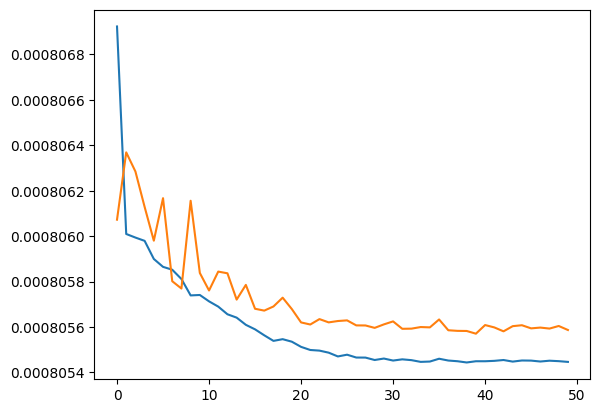

In [22]:
plt.plot(loss_value_training[:])
plt.plot(loss_value_testing[:])

In [23]:
np.save('./results/loss_value_training.npy',loss_value_training)
np.save('./results/loss_value_testing.npy',loss_value_testing)

## Define stochastic residuals

In [24]:
from nn import DiscreteEnergyConservingModel
        
# Initialize the model
input_dim = 6  # Dimensionality of the system
hidden_dim = 100  # Number of hidden units (Note: maybe try hidden_dim > input_dim)
output_dim = 6  # Dimensionality of the output
# Choose the same device as used during training (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Define Dummy Tensors to satisfy the constructor
dummy_A = torch.zeros(input_dim, input_dim).to(device)
dummy_F = torch.zeros(input_dim).to(device)

train_mean_i = np.load('./results/train_mean_i.npy')
train_std_i = np.load('./results/train_std_i.npy')
model = DiscreteEnergyConservingModel(M_init=dummy_A, 
                              F_init=dummy_F, 
                              feature_means = train_mean_i, 
                              feature_stds = train_std_i, 
                              N=input_dim, hidden_nodes=hidden_dim, orthogonal_map='exp').to(device)
# 3. Load the saved weights
checkpoint_path = "./results/best_model.pth"
state_dict = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state_dict)

model.eval() # Set to evaluation mode

DiscreteEnergyConservingModel(
  (mlp): Sequential(
    (0): Linear(in_features=6, out_features=100, bias=False)
    (1): SiLU()
    (2): Linear(in_features=100, out_features=15, bias=False)
  )
)

In [31]:
# Move input to same device
x_t_tensor_TRAIN = x_t_tensor_TRAIN.to(device)

batch_size = 10000
predicted_list = []

model.eval() # Ensure we are in eval mode
with torch.no_grad():
    for i in range(0, len(x_t_tensor_TRAIN), batch_size):
        x_batch = x_t_tensor_TRAIN[i:i+batch_size]
        
        # CHANGE: The model now outputs the next state directly
        x_next_pred = model(x_batch) 
        
        predicted_list.append(x_next_pred.cpu())

# shape (T, N)
predicted_x_next = torch.cat(predicted_list, dim=0).numpy()

In [32]:
# subtract the predicted next state from the TRUE next state
residuals = x_t_plus_1_TRAIN - predicted_x_next.T

In [33]:
### Sigma matrix

# Compute Sigma matrix through Cholesky decomposition
import scipy.linalg

# Compute covariance matrix of the residuals
cov_matrix = np.cov(residuals)

Sigma_matrix = scipy.linalg.cholesky(cov_matrix, lower=True)

np.save('./results/Sigma_matrix.npy',Sigma_matrix)

In [34]:
### Diagonal Sigma matrix (used in this work)

# Compute covariance matrix of the residuals
cov_matrix = np.cov(residuals)

# Independent noise (uncorrelated):
variances = np.diag(cov_matrix) # Extract diagonal of covariance
Sigma_matrix_identity = np.diag(np.sqrt(variances)) # Square root for standard deviation

np.save('./results/Sigma_matrix_identity.npy', Sigma_matrix_identity)

# Emulation

### Simple code to emulate

In [35]:
import torch
import numpy as np

def simulate_dynamics(x0, model, Sigma, period, transient=100):
    model.eval()

    dtype = torch.float32
    device = next(model.parameters()).device

    Sigma = torch.as_tensor(Sigma, dtype=dtype, device=device)
    x = torch.as_tensor(x0, dtype=dtype, device=device)

    n = len(x0)

    # pre-generate Gaussian noise (Great practice for performance, by the way!)
    dW = np.random.normal(0, 1, size=(n, period))

    results = []

    with torch.no_grad():
        for t in range(period):

            # CHANGE 1: The model predicts the next state directly
            x_next_det = model(x.unsqueeze(0)).squeeze(0)

            # Calculate stochastic forcing for this step
            noise = Sigma @ torch.as_tensor(dW[:, t], dtype=dtype, device=device)

            # CHANGE 2: The new state is just the deterministic prediction + noise
            x = x_next_det + noise

            # Store the state after the transient spin-up period
            if t >= transient:
                results.append(x.clone())

    print(f"Stored {len(results)} time steps.")
    return torch.stack(results).cpu().numpy()

def simulate_dynamics_fast(x0, model, Sigma, period, transient=100):
    model.eval()

    dtype = torch.float32
    device = next(model.parameters()).device
    
    # Ensure inputs are on the right device
    Sigma = torch.as_tensor(Sigma, dtype=dtype, device=device)
    x = torch.as_tensor(x0, dtype=dtype, device=device)
    n = len(x0)

    # OPTIMIZATION 1: Generate all noise directly on the target device
    # This completely eliminates 10 million CPU-to-GPU transfers.
    dW = torch.randn((n, period), dtype=dtype, device=device)
    
    # OPTIMIZATION 2: Pre-multiply Sigma and the noise. 
    # Do the matrix multiplication once for the whole sequence!
    noise_sequence = Sigma @ dW 

    # OPTIMIZATION 3: Pre-allocate the exact memory needed for the results.
    # No more lists, no more .clone(), and no massive torch.stack() at the end.
    num_saved_steps = period - transient
    results = torch.empty((num_saved_steps, n), dtype=dtype, device=device)

    with torch.no_grad():
        for t in range(period):
            
            # Predict the next state
            x_next_det = model(x.unsqueeze(0)).squeeze(0)
            
            # Add the pre-computed noise for this time step
            x = x_next_det + noise_sequence[:, t]
            
            # Write directly to the pre-allocated tensor memory
            if t >= transient:
                results[t - transient] = x

    print(f"Stored {num_saved_steps} time steps.")
    return results.cpu().numpy()

### Load model

In [36]:
# Inputs
# State vector
mean_i = np.load('./results/train_mean_i.npy')
std_i = np.load('./results/train_std_i.npy')

#time = 0
#x_0 = (x_t_all[:,time]-mean_i)/std_i
x_0 = np.random.normal(0, 1, 6)
x_0

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from nn import DiscreteEnergyConservingModel

# Initialize the model
input_dim = 6  # Dimensionality of the system
hidden_dim = 100  # Number of hidden units (Note: maybe try hidden_dim > input_dim)
output_dim = 6  # Dimensionality of the output
# Choose the same device as used during training (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Define Dummy Tensors to satisfy the constructor
dummy_A = torch.zeros(input_dim, input_dim).to(device)
dummy_F = torch.zeros(input_dim).to(device)

train_mean_i = np.load('./results/train_mean_i.npy')
train_std_i = np.load('./results/train_std_i.npy')
model = DiscreteEnergyConservingModel(M_init=dummy_A, 
                              F_init=dummy_F, 
                              feature_means = train_mean_i, 
                              feature_stds = train_std_i, 
                              N=input_dim, hidden_nodes=hidden_dim, orthogonal_map='exp').to(device)
# 3. Load the saved weights
checkpoint_path = "./results/best_model.pth"
state_dict = torch.load(checkpoint_path, map_location=torch.device('cpu'))
#state_dict = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state_dict)

# 3. Move model to device and SET TO EVAL MODE
model = model.to(device)
model.eval() # <--- Crucial for inference!

########## Noise covariance matrix
Sigma_matrix = np.load('./results/Sigma_matrix_identity.npy')

In [39]:
%%time
########## Autoregression

n_ts = len(x_0)
transient = 1000
period = 10000000 + transient

# Run and collect results
x_t = simulate_dynamics_fast(x_0, model, Sigma_matrix, period, transient=transient)

Stored 100000 time steps.
CPU times: user 30.1 s, sys: 11.7 ms, total: 30.1 s
Wall time: 30.2 s


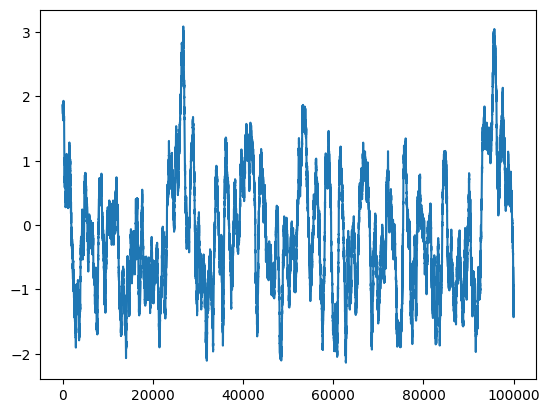

In [40]:
plt.plot(x_t[:,0])

In [41]:
# De-standardized the emulator
x_t_emulated = (x_t*std_i)+mean_i

In [42]:
np.save('./results/x_t_emulated.npy',x_t_emulated)

# First check against ground truth

In [43]:
x_t_emulated = np.load('./results/x_t_emulated.npy')

In [45]:
x_t_all = np.load('../../../../../../../Numerical/results/CdV_long_trajectory.npy').T
x_t_all = x_t_all[:,:100000]
x_t_all.shape

(6, 100000)

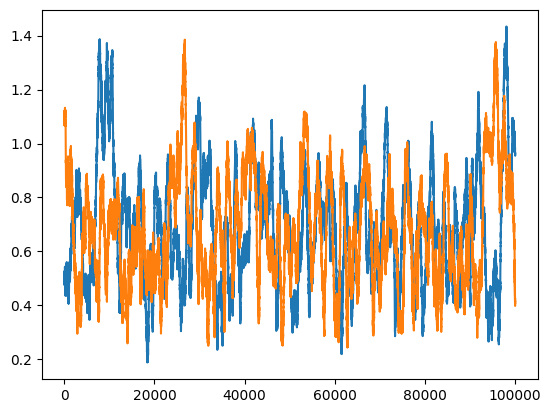

In [46]:
i = 0
plt.plot(x_t_all.T[:100000,i])
plt.plot(x_t_emulated[:100000,i],'-')

In [47]:
np.mean(x_t_emulated,0)

array([ 0.67851214, -0.11999462, -0.1241614 , -0.3718235 ,  0.06546604,
        0.07568869])

In [48]:
np.mean(x_t_all,1)

array([ 0.69264949, -0.18210351, -0.12834237, -0.37579785,  0.09657583,
        0.06802572])

In [49]:
np.std(x_t_emulated,0)

array([0.20520825, 0.25186858, 0.23544164, 0.1751441 , 0.14927479,
       0.13375181])

In [50]:
np.std(x_t_all,1)

array([0.21768094, 0.24930053, 0.23395846, 0.17201163, 0.14156966,
       0.13905173])

In [ ]:
i = 0
_ = plt.hist(x_t_all[i,:],100)
_ = plt.hist(x_t_emulated[:, i], bins=100)